In [1]:

# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
import warnings
from PIL import Image

warnings.filterwarnings('ignore')

In [2]:
import kagglehub


DATA_DIR = kagglehub.dataset_download("mdnymurrahmanshuvo/eye-emotion-dataset-diu")

BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 224
NUM_CLASSES = 6
CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise']

print(f"Using Device: {DEVICE}")

100%|██████████| 29.3M/29.3M [00:02<00:00, 10.7MB/s]

Extracting files...


Using Device: cuda


In [3]:
# ImageNet Normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Training Transforms (with Augmentation)
train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize
])

# Test/Val Transforms (No Augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    normalize
])

In [4]:
# Load datasets without transforms first

NESTED_DATASET_ROOT = os.path.join(DATA_DIR, 'eye reaction last')
full_dataset_plain = datasets.ImageFolder(root=os.path.join(NESTED_DATASET_ROOT, 'train'))  #Assigns labels based on folder names
test_dataset = datasets.ImageFolder(root=os.path.join(NESTED_DATASET_ROOT, 'test'), transform=test_transform)

train_size = int(0.8 * len(full_dataset_plain))
val_size = len(full_dataset_plain) - train_size
train_indices, val_indices = random_split(range(len(full_dataset_plain)), [train_size, val_size])


train_dataset = torch.utils.data.Subset(full_dataset_plain, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset_plain, val_indices)


class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

train_dataset = TransformedSubset(train_dataset, train_transform)
val_dataset = TransformedSubset(val_dataset, test_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset Loaded: {len(full_dataset_plain.classes)} classes -> {full_dataset_plain.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Dataset Loaded: 6 classes -> ['anger', 'disgust', 'fear', 'happy', 'sad', 'surprise']
Train: 216 | Val: 54 | Test: 138


In [5]:
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return torch.flatten(x, 1)

class HybridModel(nn.Module):
    def __init__(self, num_classes):
        super(HybridModel, self).__init__()

        # Branch 1: Custom CNN
        self.cnn = CustomCNN()

        # Branch 2: ResNet18
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity() # Remove final layer

        # Branch 3: Vision Transformer
        self.vit = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)

        # Fusion Layer
        # Dim: CNN(128) + ResNet(512) + ViT(384) = 1024
        self.classifier = nn.Sequential(
            nn.Linear(128 + 512 + 384, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        f1 = self.cnn(x)
        f2 = self.resnet(x)
        f3 = self.vit(x)
        fused = torch.cat((f1, f2, f3), dim=1)
        return self.classifier(fused)

# Initialize Model
model = HybridModel(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
    return running_loss / len(loader), 100. * correct / total

In [7]:
best_acc = 0.0

print("Starting Training...")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"--> Saved Best Model (Acc: {val_acc:.2f}%)")

print("Training Finished.")

Starting Training...
Epoch 1/30 | Train Loss: 1.6744 Acc: 29.17% | Val Loss: 1.4013 Acc: 46.30%
--> Saved Best Model (Acc: 46.30%)
Epoch 2/30 | Train Loss: 1.2177 Acc: 54.63% | Val Loss: 1.0341 Acc: 64.81%
--> Saved Best Model (Acc: 64.81%)
Epoch 3/30 | Train Loss: 0.7836 Acc: 79.63% | Val Loss: 1.0150 Acc: 57.41%
Epoch 4/30 | Train Loss: 0.5718 Acc: 84.72% | Val Loss: 0.9144 Acc: 74.07%
--> Saved Best Model (Acc: 74.07%)
Epoch 5/30 | Train Loss: 0.5248 Acc: 82.87% | Val Loss: 1.0273 Acc: 70.37%
Epoch 6/30 | Train Loss: 0.3198 Acc: 89.81% | Val Loss: 0.7310 Acc: 79.63%
--> Saved Best Model (Acc: 79.63%)
Epoch 7/30 | Train Loss: 0.2002 Acc: 94.44% | Val Loss: 0.8648 Acc: 70.37%
Epoch 8/30 | Train Loss: 0.1448 Acc: 94.91% | Val Loss: 0.8170 Acc: 72.22%
Epoch 9/30 | Train Loss: 0.2082 Acc: 91.67% | Val Loss: 0.6836 Acc: 74.07%
Epoch 10/30 | Train Loss: 0.1426 Acc: 96.76% | Val Loss: 0.9370 Acc: 68.52%
Epoch 11/30 | Train Loss: 0.0844 Acc: 97.69% | Val Loss: 0.6523 Acc: 79.63%
Epoch 12/30 

Starting Testing on Test Dataset...

--- Final Test Results ---
              precision    recall  f1-score   support

       angry       0.85      0.85      0.85        27
     disgust       0.56      0.60      0.58        15
        fear       0.84      0.91      0.88        23
       happy       0.90      0.82      0.86        34
         sad       0.85      0.81      0.83        21
    surprise       0.74      0.78      0.76        18

    accuracy                           0.81       138
   macro avg       0.79      0.80      0.79       138
weighted avg       0.82      0.81      0.81       138



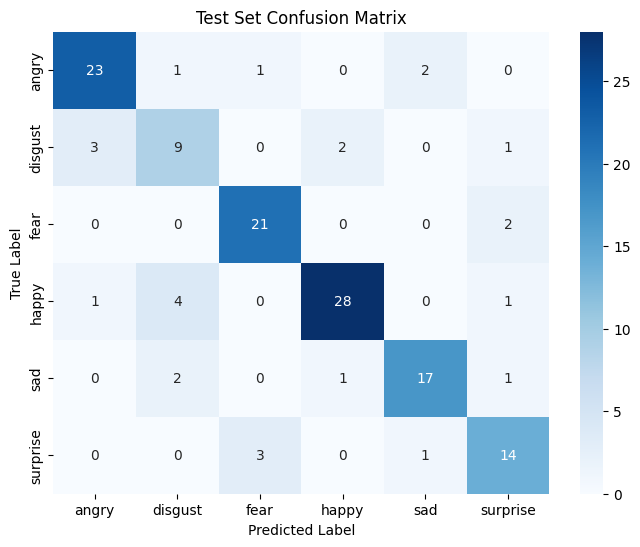

In [8]:

# TESTING CODE (Final Evaluation)


model.load_state_dict(torch.load('best_model.pth'))
model.eval()  # Set model to evaluation mode


all_preds = []
all_labels = []

print("Starting Testing on Test Dataset...")


with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # Get predictions
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Store results
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


print("\n--- Final Test Results ---")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()

In [9]:
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks to capture gradients and feature maps
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        # Gradients w.r.t the output of the target layer
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        self.model.eval()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()


        self.model.zero_grad()


        output[0][class_idx].backward(retain_graph=True)


        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])


        activations = self.activations.detach()
        for i in range(activations.shape[1]):
            activations[:, i, :, :] *= pooled_gradients[i]


        heatmap = torch.mean(activations, dim=1).squeeze()
        heatmap = F.relu(heatmap) # ReLU to keep only positive influences


        heatmap /= torch.max(heatmap)
        return heatmap.cpu().numpy(), class_idx

In [10]:
def visualize_xai(image_path, model, grad_cam, transform, class_names, device):

    original_img = Image.open(image_path).convert('RGB')
    input_tensor = transform(original_img).unsqueeze(0).to(device)


    heatmap, pred_idx = grad_cam(input_tensor)


    heatmap = cv2.resize(heatmap, (original_img.size))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)


    superimposed_img = heatmap * 0.4 + np.array(original_img) * 0.6
    superimposed_img = superimposed_img / np.max(superimposed_img)

    # 5. Get Prediction Stats
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.nn.functional.softmax(output, dim=1)[0] * 100
        confidence = probs[pred_idx].item()

    pred_class = class_names[pred_idx]

    # 6. Plotting
    plt.figure(figsize=(14, 5))

    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original Eye Image", fontsize=12)
    plt.axis('off')

    # Heatmap Only
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM Attention Map", fontsize=12)
    plt.axis('off')

    # Superimposed (Explainable Result)
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title(f"Prediction: {pred_class.upper()}\nConfidence: {confidence:.1f}%\n(Red = High Attention)", fontsize=12, color='darkblue')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Explainable AI Analysis: The model focused on the highlighted regions (Red) to predict '{pred_class}'.")

Please upload an eye image to see what the model focused on...


Saving demo 4.webp to demo 4.webp

Analyzing demo 4.webp with Explainable AI...


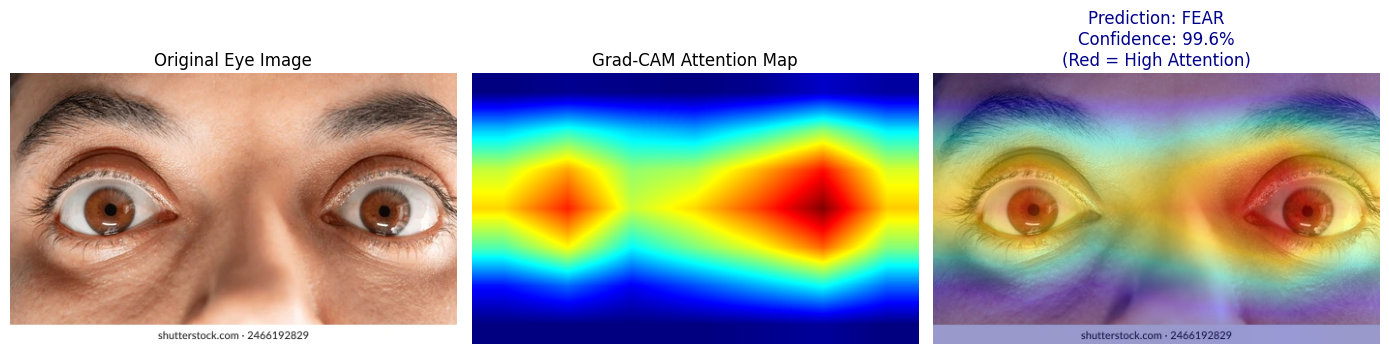

Explainable AI Analysis: The model focused on the highlighted regions (Red) to predict 'fear'.


In [13]:
# --- USAGE WITH XAI ---

# 1. Initialize GradCAM targeting the last convolutional layer of the ResNet branch
# Note: We use layer4[-1].conv2 for ResNet18
target_layer = model.resnet.layer4[-1].conv2
grad_cam = GradCAM(model, target_layer)

# 2. Upload Image
from google.colab import files # If in Colab, else remove this and use local path
print("Please upload an eye image to see what the model focused on...")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f"\nAnalyzing {fn} with Explainable AI...")
    visualize_xai(fn, model, grad_cam, test_transform, CLASS_NAMES, DEVICE)